In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.data import load_netset
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42

# Undirected features: collapsed from directed
# Directed: out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse (6 features)
# Undirected: deg_u, deg_v, sim (3 features)
FEATURE_NAMES = ['deg_u', 'deg_v', 'sim']

In [2]:
# =============================================================================
# Helper Functions (adapted for UNDIRECTED graphs)
# =============================================================================

def conformal_quantile(scores, alpha):
    """Mondrian conformal quantile."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return np.inf if k > n else np.sort(scores)[k - 1]

def get_node_features_undirected(adj, n_components=32):
    """
    Extract node features via SVD for UNDIRECTED graphs.
    
    Key difference from directed:
    - For undirected: in_deg == out_deg == deg
    - SVD on symmetric matrix: src_emb == tgt_emb, so we use single embedding
    """
    # For undirected, degree is simply the sum of each row (or column, they're equal)
    deg = np.array(adj.sum(axis=1)).flatten()
    
    # SVD embedding - for symmetric matrix, we get one embedding per node
    svd = SVD(n_components=n_components)
    emb = svd.fit_transform(adj)
    
    return deg, emb

def compute_pair_features_undirected(pairs, deg, emb):
    """
    Compute UNDIRECTED edge features.
    
    Key difference from directed:
    - Directed has 6 features: out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse
    - Undirected collapses to 3 features: deg_u, deg_v, sim
      (since in_deg == out_deg and sim_forward == sim_reverse for undirected)
    """
    u, v = pairs[:, 0], pairs[:, 1]
    
    # Single similarity (no forward/reverse distinction in undirected)
    vec_u, vec_v = emb[u], emb[v]
    norm_u = np.linalg.norm(vec_u, axis=1)
    norm_v = np.linalg.norm(vec_v, axis=1)
    norm_u[norm_u == 0] = 1e-9
    norm_v[norm_v == 0] = 1e-9
    sim = np.sum(vec_u * vec_v, axis=1) / (norm_u * norm_v)
    
    # Features: deg_u, deg_v, sim (3 features)
    return np.column_stack([deg[u], deg[v], sim])

# =============================================================================
# Efficiency metrics for prediction sets
# =============================================================================
def set_metrics(y_true, sets):
    """Compute CP metrics: coverage, avg_set_size, retention, decided_acc."""
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    avg_set_size = np.mean(sizes)
    retention = np.mean(sizes == 1)

    decided_idx = np.where(sizes == 1)[0]
    if len(decided_idx) > 0:
        y_dec = y_true[decided_idx]
        pred_dec = np.array([next(iter(sets[i])) for i in decided_idx])
        acc_dec = np.mean(pred_dec == y_dec)
    else:
        acc_dec = np.nan

    return {
        "coverage": coverage,
        "avg_set_size": avg_set_size,
        "retention": retention,
        "decided_acc": acc_dec,
    }

# =============================================================================
# Risk-coverage curve + AURC
# =============================================================================
def risk_coverage_curve(y_true, p):
    """Compute risk-coverage curve for selective prediction."""
    y_true = np.asarray(y_true)
    conf = np.abs(p - 0.5)
    order = np.argsort(-conf)
    correct = ((p >= 0.5).astype(int) == y_true).astype(float)
    cum_correct = np.cumsum(correct[order])
    coverages = np.arange(1, len(y_true) + 1) / len(y_true)
    risks = 1 - cum_correct / np.arange(1, len(y_true) + 1)
    return coverages, risks

def aurc(coverages, risks):
    """Compute Area Under Risk-Coverage curve (lower is better)."""
    return float(np.trapz(risks, coverages))

# =============================================================================
# CP prediction sets from thresholds
# =============================================================================
def cp_sets_from_thresholds(p, t_lower, t_upper):
    """Generate CP prediction sets from probability thresholds."""
    sets = []
    for pi in p:
        s = set()
        if pi <= t_lower:
            s.add(0)
        if pi >= t_upper:
            s.add(1)
        if len(s) == 0:
            s = {0, 1}  # abstain on empty
        sets.append(s)
    return sets

print("Helper functions ready (UNDIRECTED version).")

Helper functions ready (UNDIRECTED version).


In [3]:
def symmetrize_adjacency(adj):
    """
    Make adjacency matrix symmetric for undirected graph.
    
    For each edge (u,v), ensures both (u,v) and (v,u) exist.
    This is CRITICAL for undirected graphs - otherwise the graph
    is secretly treated as directed.
    """
    adj_sym = adj + adj.T
    # Binarize (in case of overlapping edges creating 2s)
    adj_sym.data = np.ones_like(adj_sym.data)
    adj_sym.setdiag(0)
    adj_sym.eliminate_zeros()
    return adj_sym

def run_pipeline_undirected(adj, name, alpha=0.10, n_runs=10, n_components=32, msg_ratio=0.7):
    """
    Run UNDIRECTED graph link prediction with conformal prediction.
    
    Key differences from directed pipeline:
    1. Adjacency is symmetrized: for each (u,v), add both (u,v) and (v,u)
    2. Degrees collapse: in_deg == out_deg == deg (2 features instead of 4)
    3. Similarities collapse: sim_forward == sim_reverse (1 feature instead of 2)
    
    Total: 3 features (deg_u, deg_v, sim) vs 6 in directed
    """
    print(f"\n{'='*70}")
    print(f"Pipeline: {name.upper()} (UNDIRECTED) | {n_runs} runs")
    print(f"{'='*70}")

    # Symmetrize the adjacency matrix
    adj = symmetrize_adjacency(adj)
    
    n_nodes = adj.shape[0]
    
    # Get unique undirected edges (u < v to avoid duplicates)
    rows, cols = adj.nonzero()
    mask = rows < cols  # Keep only (u,v) where u < v
    all_edges = np.column_stack([rows[mask], cols[mask]])
    all_pos_set = set(map(tuple, all_edges))
    # Also track reverse for quick lookup
    all_pos_set_both = all_pos_set | {(v, u) for (u, v) in all_pos_set}
    
    print(f"Graph: {n_nodes:,} nodes, {len(all_edges):,} undirected edges")
    print(f"Features: {FEATURE_NAMES} (3 features vs 6 in directed)")

    run_results = []
    last_run_data = {}

    for seed in range(n_runs):
        rng = np.random.default_rng(seed)

        edges = all_edges.copy()
        rng.shuffle(edges)

        # Split: 10% cal, 10% test, 80% train
        n = len(edges)
        n_cal = int(n * 0.1)
        n_test = int(n * 0.1)

        E_cal = edges[:n_cal]
        E_test = edges[n_cal:n_cal + n_test]
        E_train_all = edges[n_cal + n_test:]

        # OGB-style: message (SVD) + supervision (classifier)
        n_train = len(E_train_all)
        n_msg = int(n_train * msg_ratio)

        train_idx = rng.permutation(n_train)
        E_msg = E_train_all[train_idx[:n_msg]]
        E_sup = E_train_all[train_idx[n_msg:]]

        # Build SYMMETRIC representation graph from MESSAGE edges
        # For undirected: add both (u,v) and (v,u)
        msg_rows = np.concatenate([E_msg[:, 0], E_msg[:, 1]])
        msg_cols = np.concatenate([E_msg[:, 1], E_msg[:, 0]])
        adj_msg = sp.csr_matrix(
            (np.ones(len(msg_rows)), (msg_rows, msg_cols)), 
            shape=(n_nodes, n_nodes)
        )
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()

        # Get undirected node features
        deg, emb = get_node_features_undirected(adj_msg, n_components)
        
        # Track known edges (both directions for undirected)
        known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))
        known_edges_set = known_edges_set | {(v, u) for (u, v) in known_edges_set}

        def make_dataset(pos_edges, exclude_set, all_pos_set_both):
            """Create balanced dataset with positive and negative edges."""
            neg_edges = set()
            while len(neg_edges) < len(pos_edges):
                u, v = rng.integers(0, n_nodes, 2)
                if u != v and u < v:  # Canonical form for undirected
                    if (u, v) not in exclude_set and (u, v) not in all_pos_set_both:
                        neg_edges.add((u, v))
            neg_edges = np.array(list(neg_edges))

            X_pos = compute_pair_features_undirected(pos_edges, deg, emb)
            X_neg = compute_pair_features_undirected(neg_edges, deg, emb)
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            pairs = np.vstack([pos_edges, neg_edges])
            return X, y, pairs

        X_train, y_train, _ = make_dataset(E_sup, known_edges_set, all_pos_set_both)
        cal_exclude = known_edges_set | set(map(tuple, E_cal)) | {(v, u) for (u, v) in E_cal}
        X_cal, y_cal, _ = make_dataset(E_cal, cal_exclude, all_pos_set_both)
        X_test, y_test, test_pairs = make_dataset(E_test, known_edges_set, all_pos_set_both)

        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)

        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]

        # ============================================================
        # CP thresholds on full calibration set
        # ============================================================
        scores_pos = 1 - p_cal[y_cal == 1]
        scores_neg = p_cal[y_cal == 0]
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        t_lower, t_upper = q0, 1 - q1

        # ====== Evaluate on TEST ======
        cp_sets_test = cp_sets_from_thresholds(p_test, t_lower, t_upper)
        cp_m = set_metrics(y_test, cp_sets_test)

        # AUC and AURC
        auc = roc_auc_score(y_test, p_test)
        rc_cov, rc_risk = risk_coverage_curve(y_test, p_test)
        aurc_val = aurc(rc_cov, rc_risk)

        run_results.append({
            "AUC": auc,
            "AURC": aurc_val,
            "CP Coverage": cp_m['coverage'],
            "CP Avg Set Size": cp_m['avg_set_size'],
            "CP Retention": cp_m['retention'],
            "CP Decided Acc": cp_m['decided_acc'],
        })

        last_run_data = {
            'y_test': y_test, 'p_test': p_test, 'cp_sets_test': cp_sets_test,
            't_lower': t_lower, 't_upper': t_upper,
            'auc': auc, 'aurc': aurc_val, 'rc_cov': rc_cov, 'rc_risk': rc_risk,
        }

        print(f"Run {seed+1}/{n_runs}: AUC={auc:.4f} | AURC={aurc_val:.4f} | "
              f"CP[Cov={cp_m['coverage']:.3f}, Ret={cp_m['retention']:.3f}, Acc={cp_m['decided_acc']:.3f}]")

    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()

    print(f"\n{'='*60}")
    print(f"RESULTS ({name.upper()} - UNDIRECTED)")
    print(f"{'='*60}")
    print(f"  AUC             : {means['AUC']:.4f} +/- {stds['AUC']:.4f}")
    print(f"  AURC            : {means['AURC']:.4f} +/- {stds['AURC']:.4f}")
    print(f"\n--- CP (alpha={alpha}) ---")
    print(f"  Coverage        : {means['CP Coverage']:.4f} +/- {stds['CP Coverage']:.4f}  (target: {1-alpha:.2f})")
    print(f"  Avg Set Size    : {means['CP Avg Set Size']:.4f} +/- {stds['CP Avg Set Size']:.4f}")
    print(f"  Retention       : {means['CP Retention']:.4f} +/- {stds['CP Retention']:.4f}")
    print(f"  Decided Acc     : {means['CP Decided Acc']:.4f} +/- {stds['CP Decided Acc']:.4f}")

    # Visualization (3 plots)
    y_test, p_test = last_run_data['y_test'], last_run_data['p_test']
    t_lower, t_upper = last_run_data['t_lower'], last_run_data['t_upper']
    cp_sets = last_run_data['cp_sets_test']
    rc_cov, rc_risk = last_run_data['rc_cov'], last_run_data['rc_risk']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{name.upper()} Results (UNDIRECTED)', fontsize=14, fontweight='bold')

    # Plot 1: Risk-Coverage curve
    ax = axes[0]
    ax.plot(rc_cov, rc_risk, color='purple', linewidth=2, label=f'AURC={last_run_data["aurc"]:.4f}')
    ax.fill_between(rc_cov, rc_risk, alpha=0.3, color='purple')
    ax.set_xlabel('Coverage'); ax.set_ylabel('Risk (1 - Accuracy)')
    ax.set_title('Risk-Coverage Curve'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 2: Probability distributions
    ax = axes[1]
    ax.hist(p_test[y_test == 0], bins=30, alpha=0.5, color='red', label='No Edge', density=True)
    ax.hist(p_test[y_test == 1], bins=30, alpha=0.5, color='blue', label='Edge', density=True)
    ax.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    ax.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
    ax.set_title('CP Thresholds'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 3: Set sizes
    ax = axes[2]
    sizes = [len(s) for s in cp_sets]
    unique, counts = np.unique(sizes, return_counts=True)
    colors_bar = ['green' if u == 1 else 'orange' for u in unique]
    ax.bar(unique, counts, color=colors_bar, alpha=0.7)
    ax.set_xlabel('Set Size'); ax.set_ylabel('Count')
    ax.set_title(f'Set Size Distribution (Ret={means["CP Retention"]:.1%})')
    ax.set_xticks(unique); ax.set_xticklabels(['Decided' if u == 1 else 'Abstain' for u in unique])
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return {'name': name, 'df': df, 'means': df.mean().to_dict(), 'last_run': last_run_data}

print("Pipeline ready (UNDIRECTED version).")

Pipeline ready (UNDIRECTED version).


In [4]:
def load_and_prepare_undirected(dataset_name):
    """
    Load dataset and prepare for undirected graph processing.
    
    Note: The symmetrization is done in the pipeline to allow proper
    edge counting before and after.
    """
    data = load_netset(dataset_name)
    adj = data.adjacency
    names = data.names if hasattr(data, 'names') else None
    
    # Ensure sparse CSR format
    if not sp.isspmatrix_csr(adj):
        adj = sp.csr_matrix(adj)
    
    adj.setdiag(0)
    adj.eliminate_zeros()
    
    print(f"Loaded {dataset_name}: {adj.shape[0]:,} nodes, {adj.nnz:,} edges (before symmetrization)")
    return adj, names

In [5]:
# Configuration for UNDIRECTED graphs
# Using datasets that are naturally undirected or can be treated as such
DATASETS = ['citeseer', 'openflights']

N_RUNS = 10
ALPHA = 0.10
N_COMPONENTS = 32

all_results = []

print("="*70)
print("UNDIRECTED GRAPH LINK PREDICTION WITH CONFORMAL PREDICTION")
print("="*70)
print(f"\nDatasets: {DATASETS}")
print(f"Features: {FEATURE_NAMES}")
print(f"\nKey differences from directed:")
print("  - Adjacency symmetrized: (u,v) implies (v,u)")
print("  - Degrees collapsed: in_deg == out_deg == deg")
print("  - Similarities collapsed: sim_forward == sim_reverse == sim")
print(f"  - 3 features vs 6 in directed version")

UNDIRECTED GRAPH LINK PREDICTION WITH CONFORMAL PREDICTION

Datasets: ['citeseer', 'openflights']
Features: ['deg_u', 'deg_v', 'sim']

Key differences from directed:
  - Adjacency symmetrized: (u,v) implies (v,u)
  - Degrees collapsed: in_deg == out_deg == deg
  - Similarities collapsed: sim_forward == sim_reverse == sim
  - 3 features vs 6 in directed version


Unpacking archive...
Parsing files...
Done.
Loaded citeseer: 3,264 nodes, 9,072 edges (before symmetrization)

Pipeline: CITESEER (UNDIRECTED) | 10 runs
Graph: 3,264 nodes, 4,536 undirected edges
Features: ['deg_u', 'deg_v', 'sim'] (3 features vs 6 in directed)


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.7715 | AURC=0.1667 | CP[Cov=0.906, Ret=0.485, Acc=0.806]


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.7356 | AURC=0.1974 | CP[Cov=0.914, Ret=0.443, Acc=0.805]


...

Run 8/10: AUC=0.7463 | AURC=0.1807 | CP[Cov=0.911, Ret=0.467, Acc=0.809]


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.7446 | AURC=0.1905 | CP[Cov=0.927, Ret=0.411, Acc=0.823]


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.7740 | AURC=0.1713 | CP[Cov=0.923, Ret=0.449, Acc=0.828]

RESULTS (CITESEER - UNDIRECTED)
  AUC             : 0.7611 +/- 0.0182
  AURC            : 0.1770 +/- 0.0130

--- CP (alpha=0.1) ---
  Coverage        : 0.9179 +/- 0.0076  (target: 0.90)
  Avg Set Size    : 1.5511 +/- 0.0254
  Retention       : 0.4489 +/- 0.0254
  Decided Acc     : 0.8172 +/- 0.0119


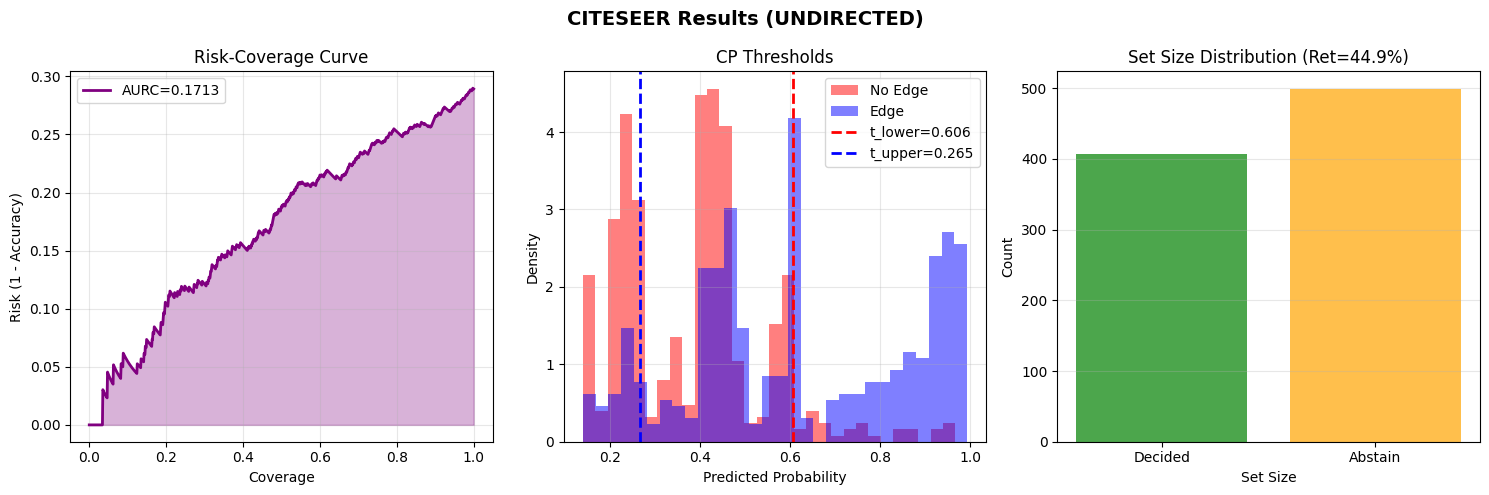

In [6]:
# Run CiteSeer
adj, names = load_and_prepare_undirected('citeseer')
result = run_pipeline_undirected(adj, 'CiteSeer', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

Unpacking archive...
Parsing files...
Done.
Loaded openflights: 3,097 nodes, 36,386 edges (before symmetrization)

Pipeline: OPENFLIGHTS (UNDIRECTED) | 10 runs
Graph: 3,097 nodes, 18,193 undirected edges
Features: ['deg_u', 'deg_v', 'sim'] (3 features vs 6 in directed)


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 1/10: AUC=0.9643 | AURC=0.0223 | CP[Cov=0.917, Ret=0.979, Acc=0.915]


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 2/10: AUC=0.9620 | AURC=0.0244 | CP[Cov=0.903, Ret=1.000, Acc=0.903]


...

Run 8/10: AUC=0.9588 | AURC=0.0267 | CP[Cov=0.903, Ret=1.000, Acc=0.903]


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 9/10: AUC=0.9615 | AURC=0.0253 | CP[Cov=0.902, Ret=0.998, Acc=0.902]


C:\Users\longv\AppData\Local\Temp\ipykernel_17556\2575609782.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


Run 10/10: AUC=0.9614 | AURC=0.0239 | CP[Cov=0.906, Ret=0.995, Acc=0.905]

RESULTS (OPENFLIGHTS - UNDIRECTED)
  AUC             : 0.9611 +/- 0.0023
  AURC            : 0.0251 +/- 0.0019

--- CP (alpha=0.1) ---
  Coverage        : 0.9089 +/- 0.0065  (target: 0.90)
  Avg Set Size    : 1.0082 +/- 0.0093
  Retention       : 0.9918 +/- 0.0093
  Decided Acc     : 0.9081 +/- 0.0059


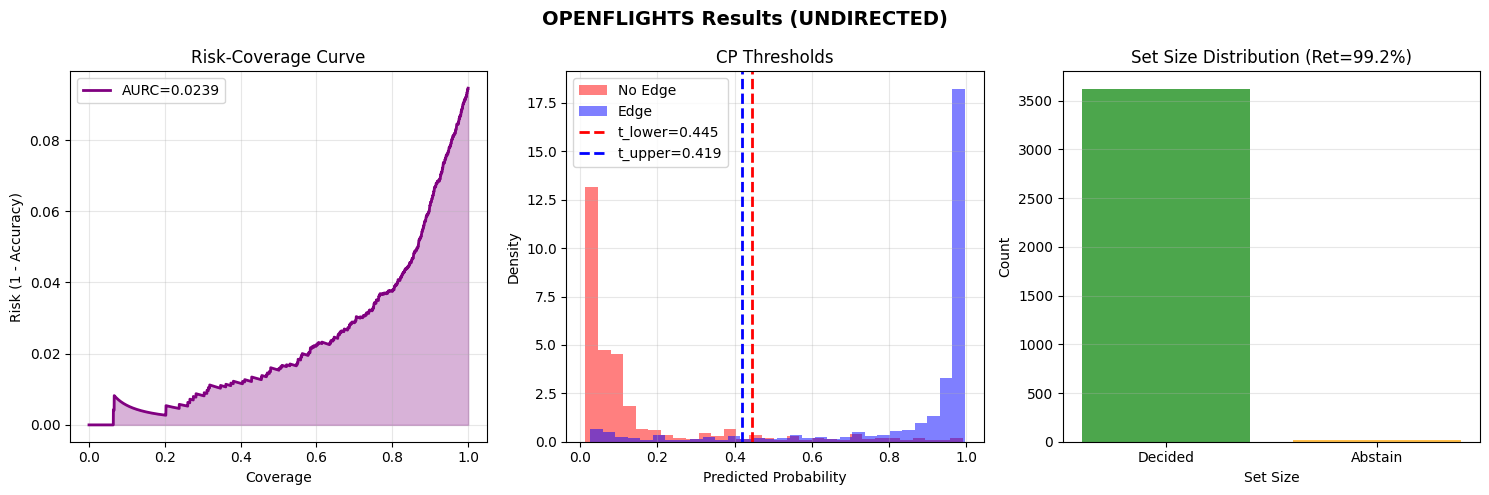

In [7]:
# Run OpenFlights
adj, names = load_and_prepare_undirected('openflights')
result = run_pipeline_undirected(adj, 'OpenFlights', alpha=ALPHA, n_runs=N_RUNS, n_components=N_COMPONENTS)
all_results.append(result)

In [8]:
# Comparison Summary
print("\n" + "="*80)
print("COMPARISON ACROSS ALL UNDIRECTED DATASETS")
print("="*80)

comparison_data = []
for r in all_results:
    row = {'Dataset': r['name']}
    row.update(r['means'])
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n--- Key Findings ---")
print(f"Best AUC: {comparison_df.loc[comparison_df['AUC'].idxmax(), 'Dataset']} ({comparison_df['AUC'].max():.4f})")
print(f"Best AURC: {comparison_df.loc[comparison_df['AURC'].idxmin(), 'Dataset']} ({comparison_df['AURC'].min():.4f})")
print(f"Highest CP Retention: {comparison_df.loc[comparison_df['CP Retention'].idxmax(), 'Dataset']} ({comparison_df['CP Retention'].max():.4f})")


COMPARISON ACROSS ALL UNDIRECTED DATASETS
    Dataset      AUC     AURC  CP Coverage  CP Avg Set Size  CP Retention  CP Decided Acc
   CiteSeer 0.761133 0.177034     0.917881         1.551104      0.448896        0.817154
OpenFlights 0.961080 0.025140     0.908851         1.008219      0.991781        0.908137

--- Key Findings ---
Best AUC: OpenFlights (0.9611)
Best AURC: OpenFlights (0.0251)
Highest CP Retention: OpenFlights (0.9918)


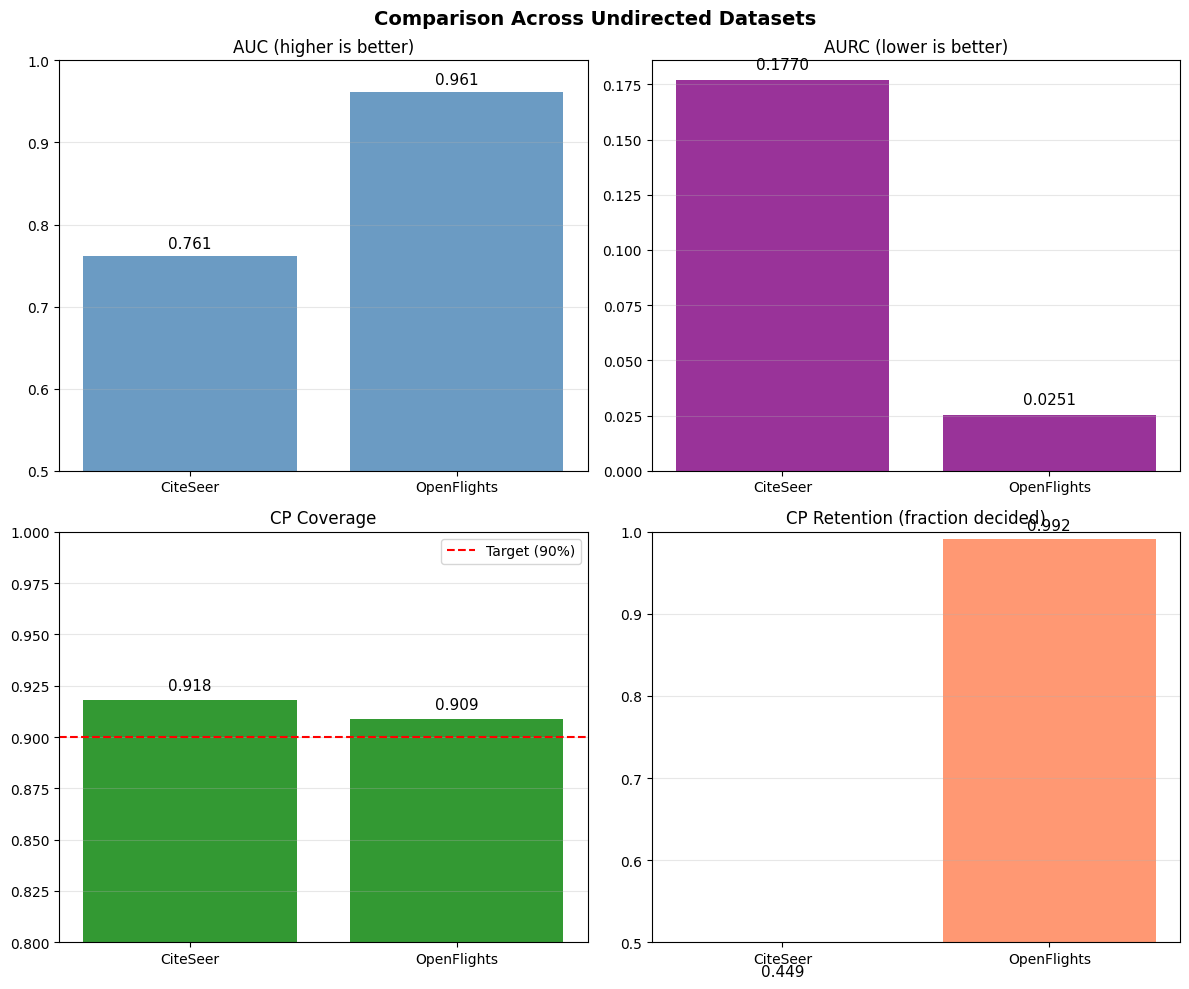

In [9]:
# Comparison Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

datasets = [r['name'] for r in all_results]

# Plot 1: AUC
ax = axes[0, 0]
values = [r['means']['AUC'] for r in all_results]
bars = ax.bar(datasets, values, color='steelblue', alpha=0.8)
ax.set_title('AUC (higher is better)')
ax.set_ylim(0.5, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.grid(alpha=0.3, axis='y')

# Plot 2: AURC
ax = axes[0, 1]
values = [r['means']['AURC'] for r in all_results]
bars = ax.bar(datasets, values, color='purple', alpha=0.8)
ax.set_title('AURC (lower is better)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.grid(alpha=0.3, axis='y')

# Plot 3: CP Coverage vs Target
ax = axes[1, 0]
values = [r['means']['CP Coverage'] for r in all_results]
bars = ax.bar(datasets, values, color='green', alpha=0.8)
ax.axhline(0.9, color='red', linestyle='--', label='Target (90%)')
ax.set_title('CP Coverage')
ax.set_ylim(0.8, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Plot 4: CP Retention
ax = axes[1, 1]
values = [r['means']['CP Retention'] for r in all_results]
bars = ax.bar(datasets, values, color='coral', alpha=0.8)
ax.set_title('CP Retention (fraction decided)')
ax.set_ylim(0.5, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Comparison Across Undirected Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Summary Table
print("\n" + "="*80)
print("FINAL SUMMARY TABLE (UNDIRECTED)")
print("="*80)

summary_cols = ['Dataset', 'AUC', 'AURC', 'CP Coverage', 'CP Avg Set Size', 'CP Retention', 'CP Decided Acc']
print(comparison_df[summary_cols].to_string(index=False))

print("\n--- Conclusions ---")
print("1. Undirected pipeline uses 3 features: deg_u, deg_v, sim")
print("2. Coverage ~0.90: CP achieves validity (target 1-alpha) on all datasets.")
print("3. Directed version would add: asymmetric degrees (in/out) + asymmetric similarities")


FINAL SUMMARY TABLE (UNDIRECTED)
    Dataset      AUC     AURC  CP Coverage  CP Avg Set Size  CP Retention  CP Decided Acc
   CiteSeer 0.761133 0.177034     0.917881         1.551104      0.448896        0.817154
OpenFlights 0.961080 0.025140     0.908851         1.008219      0.991781        0.908137

--- Conclusions ---
1. Undirected pipeline uses 3 features: deg_u, deg_v, sim
2. Coverage ~0.90: CP achieves validity (target 1-alpha) on all datasets.
3. Directed version would add: asymmetric degrees (in/out) + asymmetric similarities


In [11]:
# Display final table
display(comparison_df.round(4))

,Dataset,AUC,AURC,CP Coverage,CP Avg Set Size,CP Retention,CP Decided Acc
0,CiteSeer,0.7611,0.1770,0.9179,1.5511,0.4489,0.8172
1,OpenFlights,0.9611,0.0251,0.9089,1.0082,0.9918,0.9081
